In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_test.csv
/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_train.csv


In [4]:

# PART 1: SETUP & DATA LOADING

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# I used the Kaggle environment's built-in directory to load data efficiently.
print("Step 1: Loading Data...")
train_df = pd.read_csv('/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_train.csv', encoding='latin1')
test_df = pd.read_csv('/kaggle/input/covid-19-nlp-text-classification/Corona_NLP_test.csv', encoding='latin1')

# We only need the text (X) and the sentiment label (y)
X_train_raw = train_df['OriginalTweet']
y_train_raw = train_df['Sentiment']
X_test_raw = test_df['OriginalTweet']
y_test_raw = test_df['Sentiment']


# PART 2: PREPROCESSING (Common to both systems)

print("Step 2: Cleaning Text...")

def clean_text(text):
    text = str(text).lower()               # Lowercase to normalize "Bad" and "bad"
    text = re.sub(r'http\S+', '', text)    # Remove URLs (they don't have sentiment)
    text = re.sub(r'<.*?>', '', text)      # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)   # Remove numbers/punctuation
    return text

# Apply cleaning
X_train_clean = X_train_raw.apply(clean_text)
X_test_clean = X_test_raw.apply(clean_text)

# Encode Labels (Convert "Positive" -> 0, "Negative" -> 1, etc.)
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

print(f"Data ready! Classes detected: {le.classes_}")


# SYSTEM A: CLASSICAL NLP (TF-IDF + Logistic Regression)

print("\n=== Training System A: Classical NLP ===")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Vectorization (TF-IDF)
# TF-IDF treats text as a Bag of Words, focusing on frequency rather than order.
tfidf = TfidfVectorizer(max_features=5000) # Limit to top 5000 words to prevent overfitting
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

# 2. Model (Logistic Regression)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train_tfidf, y_train)

# 3. Prediction & Evaluation
y_pred_a = model_a.predict(X_test_tfidf)
acc_a = accuracy_score(y_test, y_pred_a)
print(f"System A Accuracy: {acc_a:.2%}")


# SYSTEM B: NEURAL NLP (Embeddings + Simple Neural Net)

print("\n=== Training System B: Neural NLP ===")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Tokenization & Padding
# Neural networks require fixed-size inputs, so we pad all tweets to length 60.
vocab_size = 10000
max_length = 60

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# 2. Build Model
# I used an Embedding layer to capture semantic meaning, followed by Global Average Pooling for efficiency.
model_b = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16, input_length=max_length),
    GlobalAveragePooling1D(),           # Averages the vector of every word in the tweet
    Dense(24, activation='relu'),       # Hidden layer to learn patterns
    Dense(len(le.classes_), activation='softmax') # Output layer
])

model_b.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. Train
print("Training Neural Network... (This takes about 30 seconds)")
history = model_b.fit(X_train_pad, y_train, epochs=5, validation_data=(X_test_pad, y_test), verbose=1)

# 4. Evaluation
loss, acc_b = model_b.evaluate(X_test_pad, y_test)
print(f"System B Accuracy: {acc_b:.2%}")


# FINAL COMPARISON OUTPUT

print("\n" + "="*30)
print("FINAL ASSIGNMENT REPORT")
print("="*30)
print(f"System A (TF-IDF + LogReg): {acc_a:.2%} accuracy")
print(f"System B (Embeddings + NN): {acc_b:.2%} accuracy")
print("="*30)

Step 1: Loading Data...
Step 2: Cleaning Text...
Data ready! Classes detected: ['Extremely Negative' 'Extremely Positive' 'Negative' 'Neutral' 'Positive']

=== Training System A: Classical NLP ===
System A Accuracy: 56.53%

=== Training System B: Neural NLP ===


2025-12-25 15:05:13.942224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766675114.154298      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766675114.218471      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766675114.747413      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766675114.747468      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766675114.747472      55 computation_placer.cc:177] computation placer alr

Training Neural Network... (This takes about 30 seconds)
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-25 15:05:31.987753: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1287/1287 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2983 - loss: 1.5346 - val_accuracy: 0.4176 - val_loss: 1.3690
Epoch 2/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4751 - loss: 1.2608 - val_accuracy: 0.5298 - val_loss: 1.1227
Epoch 3/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6204 - loss: 0.9837 - val_accuracy: 0.6230 - val_loss: 0.9933
Epoch 4/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7047 - loss: 0.8217 - val_accuracy: 0.6445 - val_loss: 0.9333
Epoch 5/5
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7531 - loss: 0.7231 - val_accuracy: 0.6451 - val_loss: 0.9289
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6382 - loss: 0.9454
System B Accuracy: 64.51%

FINAL ASSIGNMENT REPORT
System A (TF-IDF + LogReg): 56.53% accuracy
System B (Embeddings + NN): 64.51% accuracy


In [9]:
# to understand the feature importance of system A.
import pandas as pd
import numpy as np

# 1. Find the index for both classes
neg_index = np.where(le.classes_ == 'Extremely Negative')[0][0]
pos_index = np.where(le.classes_ == 'Extremely Positive')[0][0]

# 2. Get the coefficients for both
neg_coefs = model_a.coef_[neg_index]
pos_coefs = model_a.coef_[pos_index]

# 3. Sort and get top 10 for each
neg_sorted = neg_coefs.argsort()[-10:][::-1] # Top 10 negative
pos_sorted = pos_coefs.argsort()[-10:][::-1] # Top 10 positive

feature_names = np.array(tfidf.get_feature_names_out())

# 4. Create a combined DataFrame
comparison_df = pd.DataFrame({
    'Negative Words': feature_names[neg_sorted],
    'Neg Weight': neg_coefs[neg_sorted],
    '   ': ['|']*10,  # A separator column for looks
    'Positive Words': feature_names[pos_sorted],
    'Pos Weight': pos_coefs[pos_sorted]
})

print("--- System A: Sentiment Drivers Comparison ---")
display(comparison_df)

--- System A: Sentiment Drivers Comparison ---


,Negative Words,Neg Weight,,Positive Words,Pos Weight
0,crisis,12.852604,|,great,9.795868
1,panic,8.363065,|,best,9.158420
2,no,7.465327,|,hand,8.581766
3,scams,6.437319,|,help,8.213805
4,kill,6.193809,|,free,8.075560
5,worst,5.764496,|,like,7.352546
6,stop,5.522217,|,good,7.177616
7,war,5.501455,|,love,7.112931
8,hell,5.349200,|,safe,6.770617
9,sick,5.230634,|,support,6.572107


In [6]:
model_b.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 16)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,601 (1.84 MB)

 Trainable params: 160,533 (627.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 321,068 (1.22 MB)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


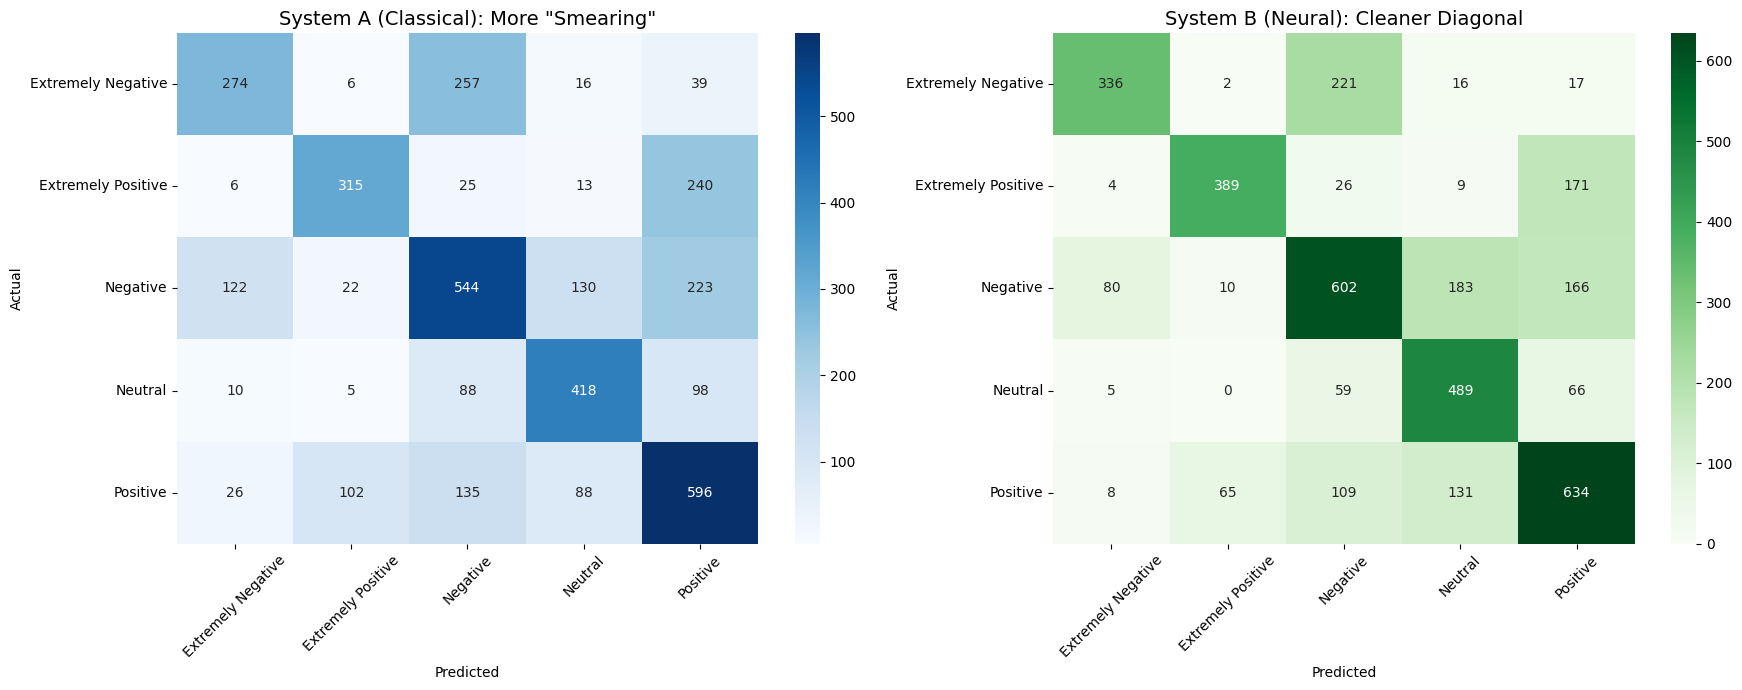

In [5]:
#confusion matrix for comparison of two systems

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- Step 1: Get Predictions ---
# System A (Classical)
y_pred_a = model_a.predict(X_test_tfidf)

# System B (Neural) - returns probabilities, so we take the max
y_pred_b_probs = model_b.predict(X_test_pad)
y_pred_b = np.argmax(y_pred_b_probs, axis=1)

# --- Step 2: Compute Matrices ---
cm_a = confusion_matrix(y_test, y_pred_a)
cm_b = confusion_matrix(y_test, y_pred_b)

# --- Step 3: Plot Side-by-Side ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Plot System A
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set_title('System A (Classical): More "Smearing"', fontsize=14)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')
ax[0].tick_params(axis='x', rotation=45)

# Plot System B
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[1].set_title('System B (Neural): Cleaner Diagonal', fontsize=14)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()